# Alpha Sweep (Absolute Error) Experiment Analysis
Analysis of how the `alpha` hyperparameter affects metrics when using Absolute Error weights. 
Experiment: `alpha_eps01_b1000_abserr`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# Load aggregated data
csv_path = '../experiments_alpha_eps01_b1000_abserr.csv'
if not os.path.exists(csv_path):
    csv_path = '../experiment_results_summary.csv' # Fallback
    
df = pd.read_csv(csv_path)

# Filter for this specific experiment
df = df[df['experiment_name'].str.contains('alpha_eps01_b1000_abserr', na=False)].copy()

# Map new flattened column names to expected shorter names
rename_map = {
    'meta_repairer_params_alpha': 'alpha',
    'meta_obtainer_params_k': 'k',
    'meta_obtainer_params_selection_budget': 'sel_budget',
    'meta_obtainer_params_generation_budget': 'gen_budget',
    'meta_synthesizer_params_seed': 'seed',
    'meta_synthesizer_params_size': 'iters'
}
df = df.rename(columns=rename_map)

# Clean up names
df['repairer'] = df['repairer'].str.replace('Repairer', '').str.replace('VC', '-VC')
df['engine'] = df['engine'].fillna('Unknown')

print(f"Total Alpha Sweep records: {len(df)}")
print("Records by Dataset:", df.groupby('dataset').size().to_dict())
print("Records by Engine:", df.groupby('engine').size().to_dict())
print("Alphas present:", sorted(df['alpha'].unique()))


Total Alpha Sweep records: 192
Records by Dataset: {'adult': 17, 'census': 81, 'compas': 52, 'tax': 42}
Records by Engine: {'aim': 90, 'mst': 102}
Alphas present: [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]


## Visualizing Metrics vs. Alpha


Dataset: ADULT



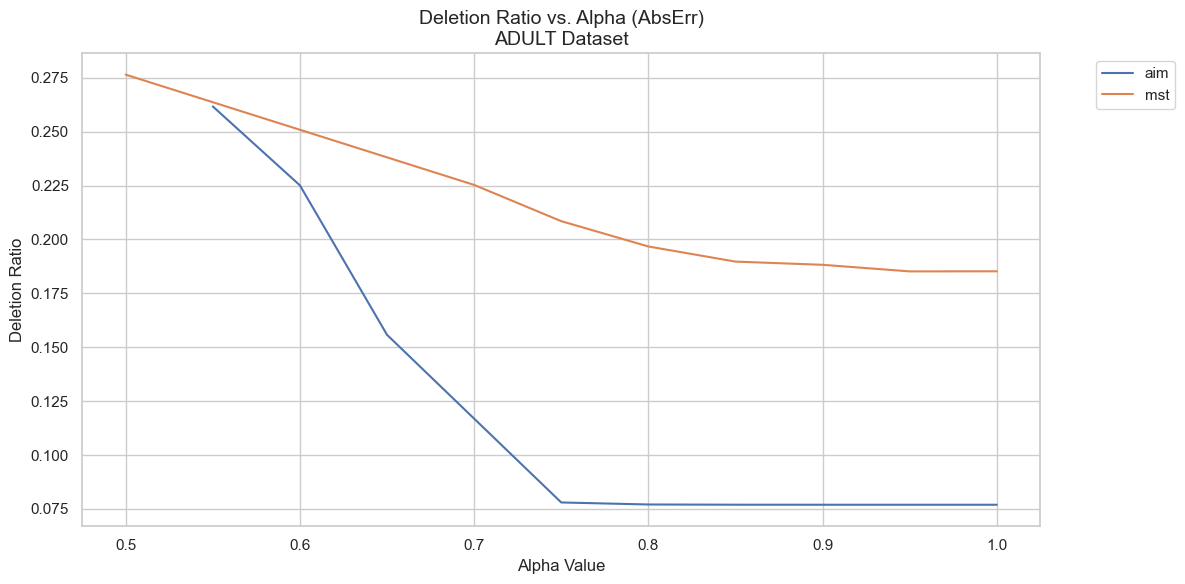

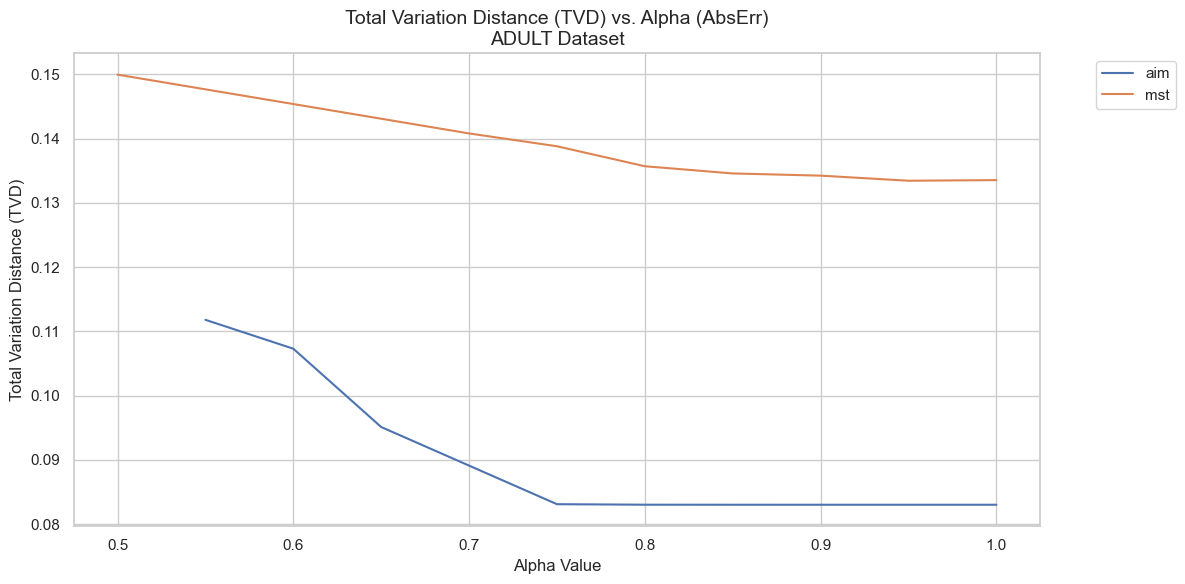

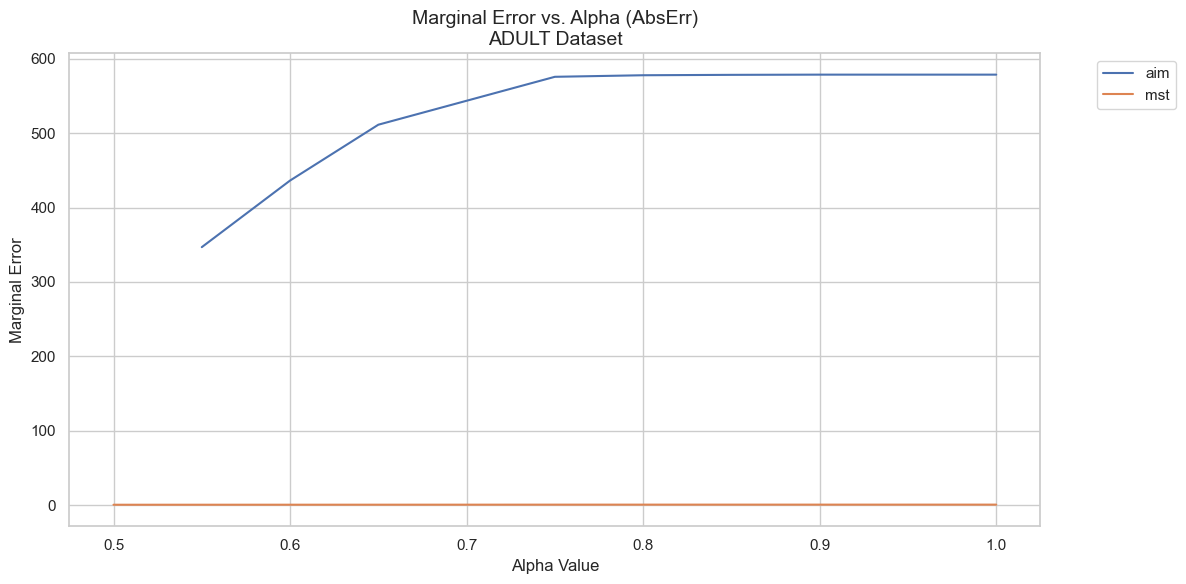

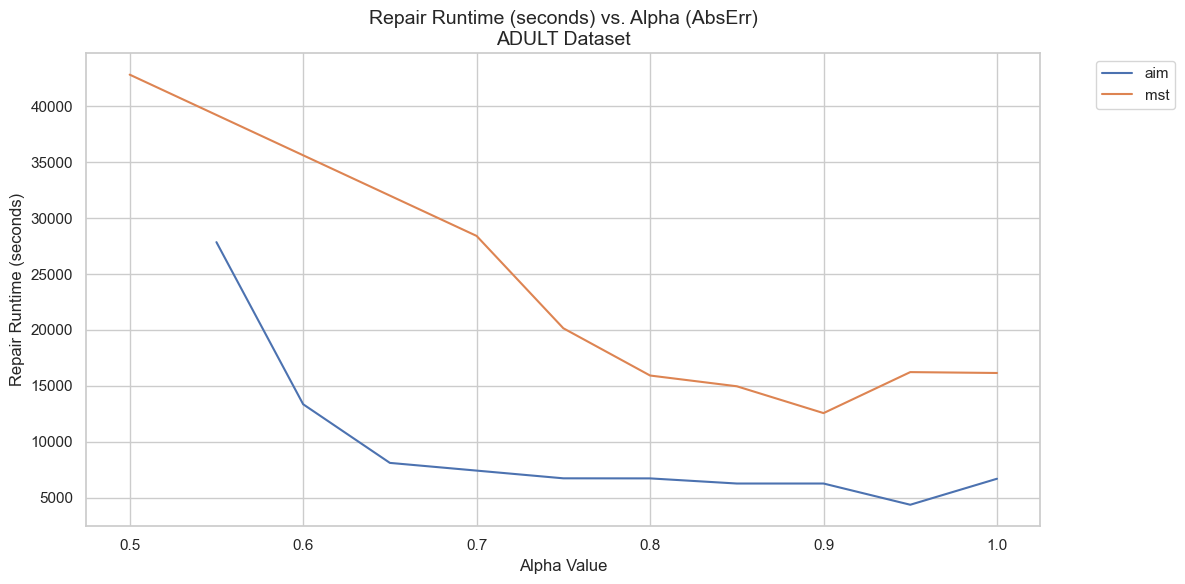

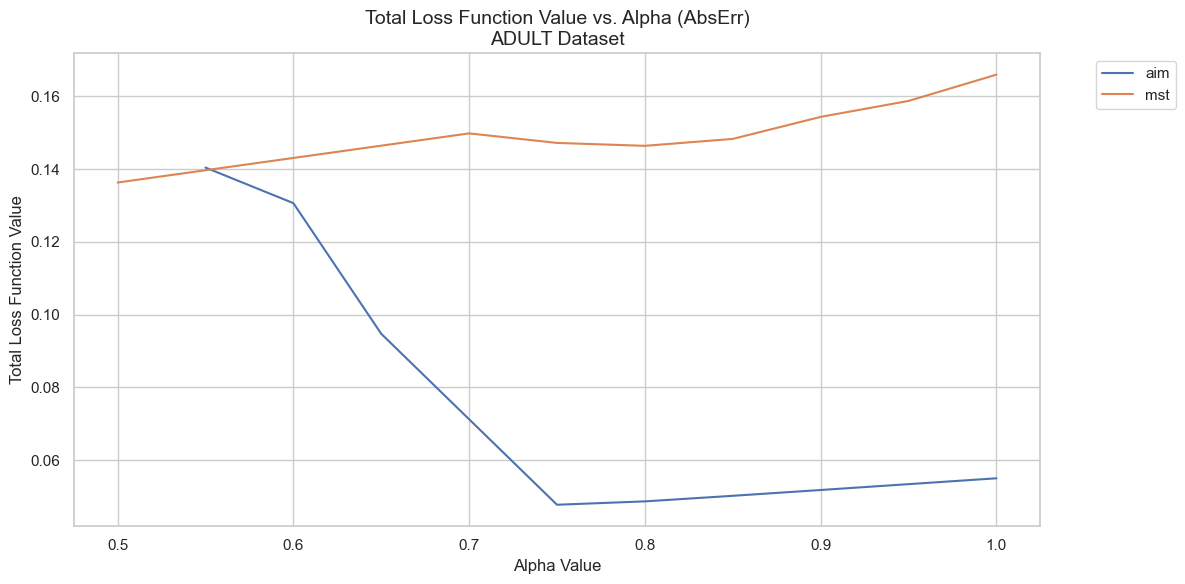

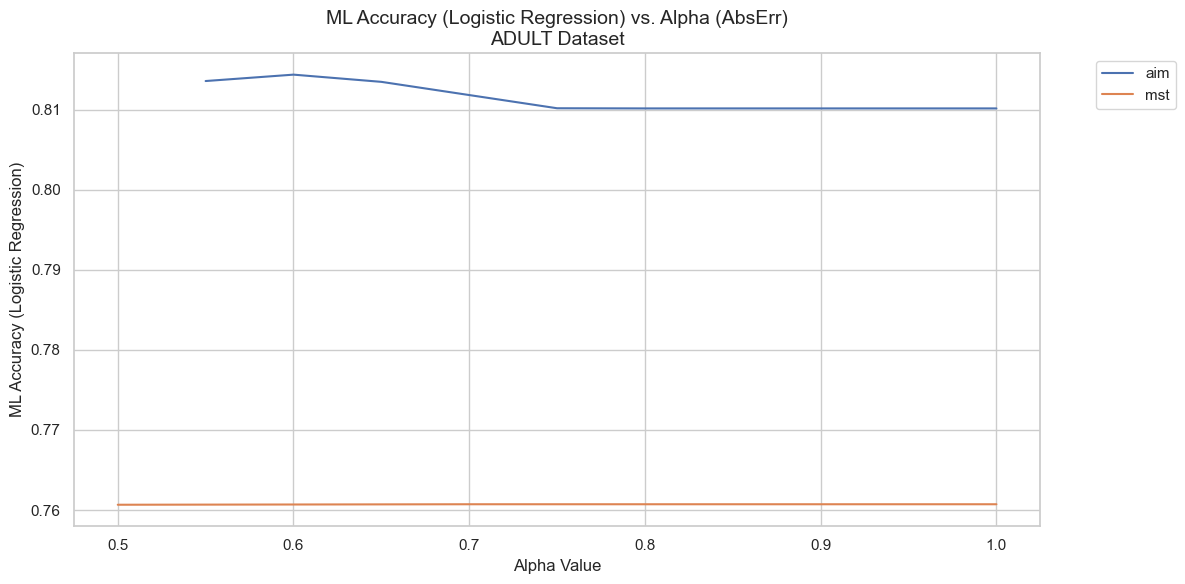


Dataset: CENSUS



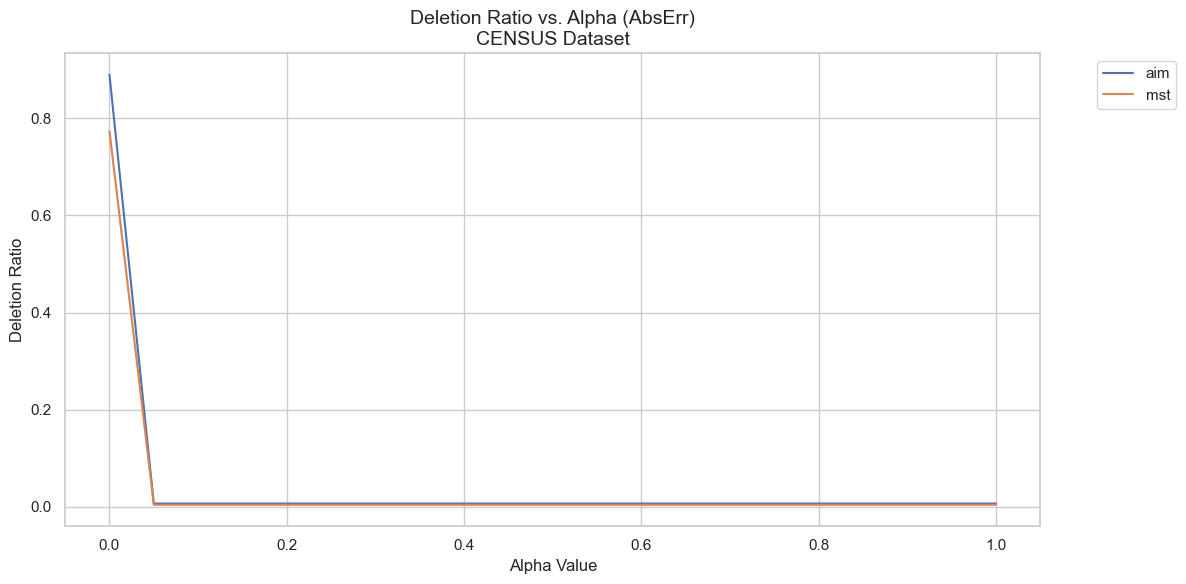

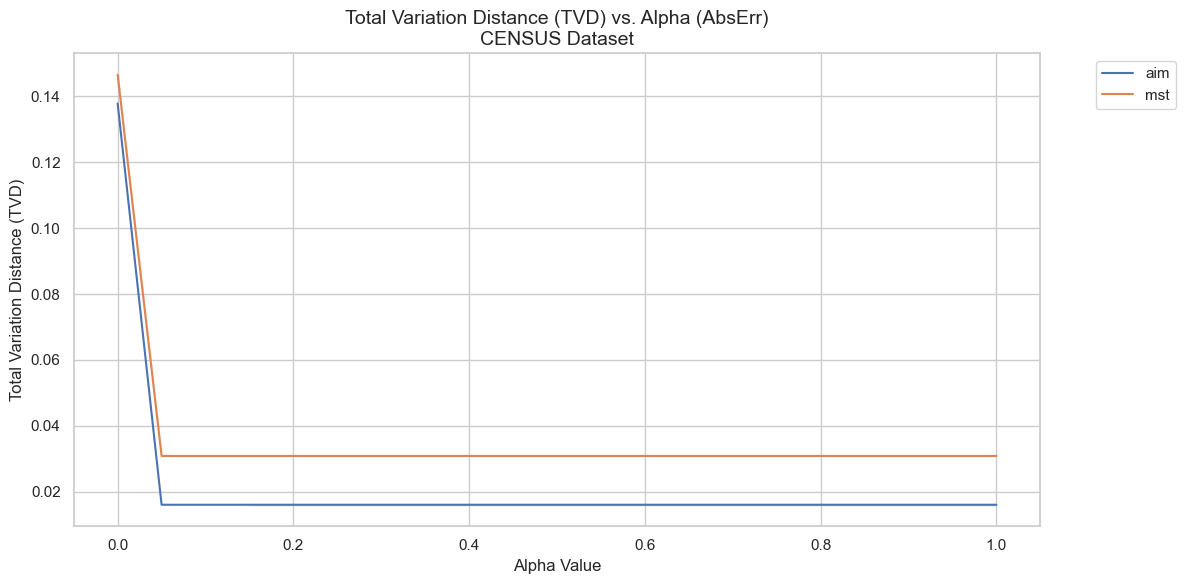

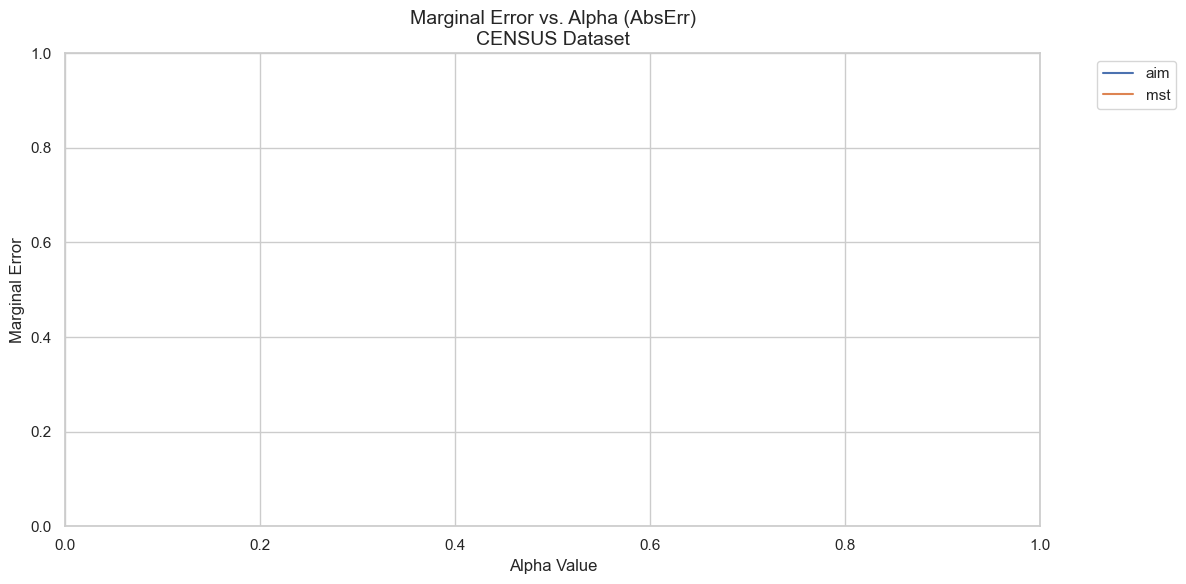

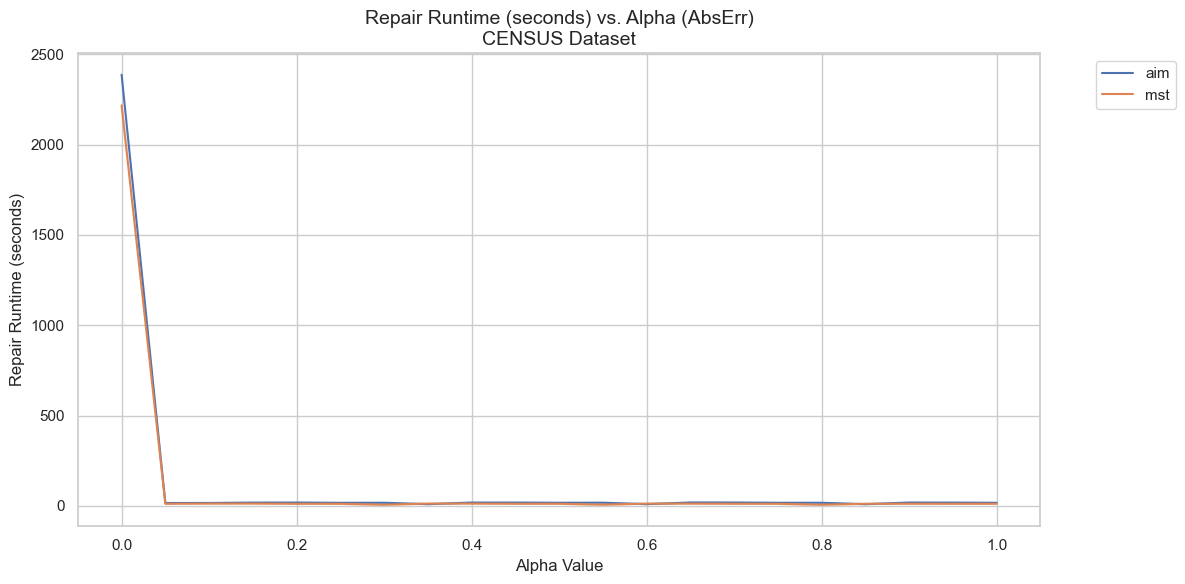

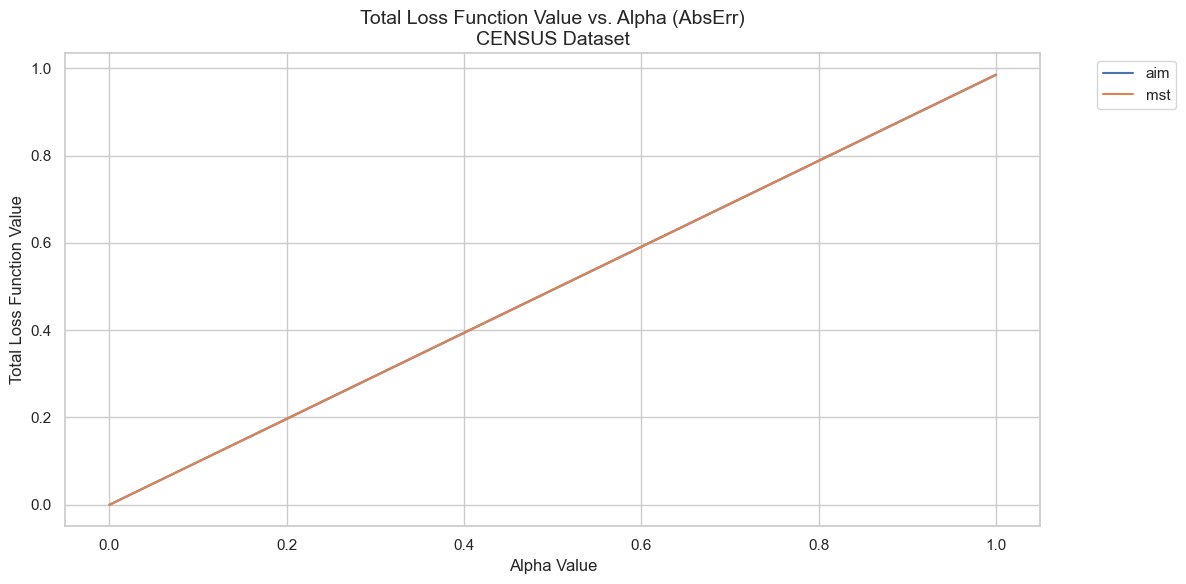

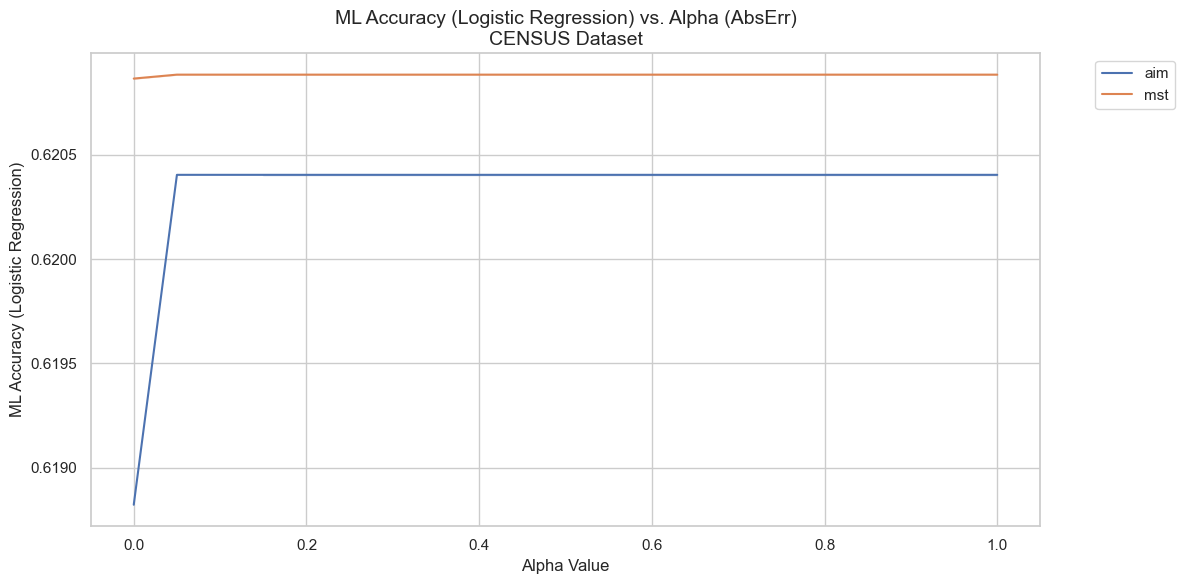


Dataset: COMPAS



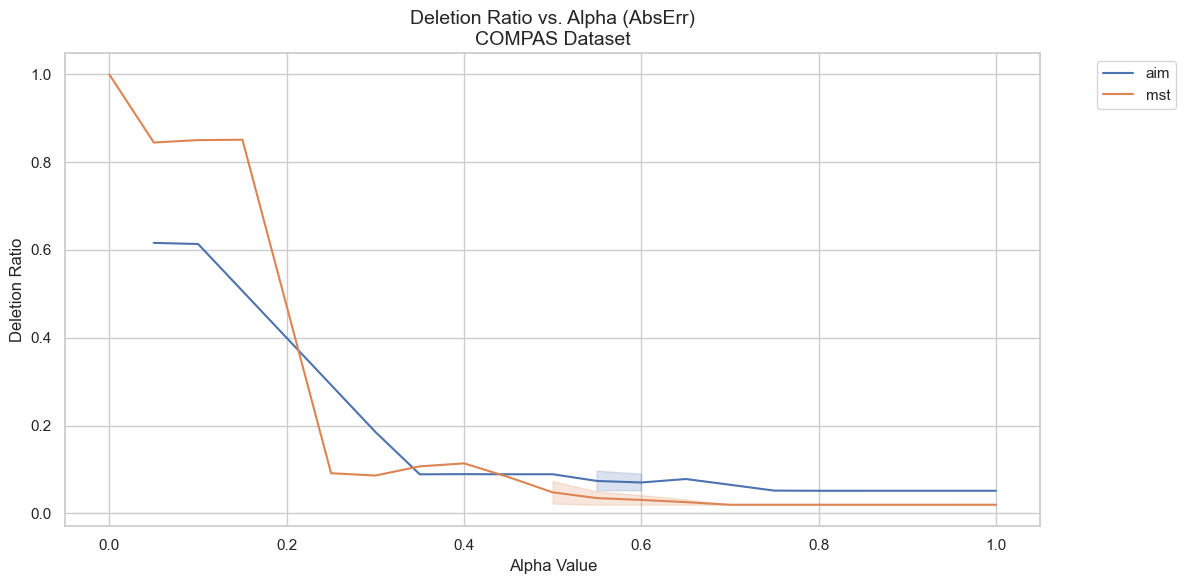

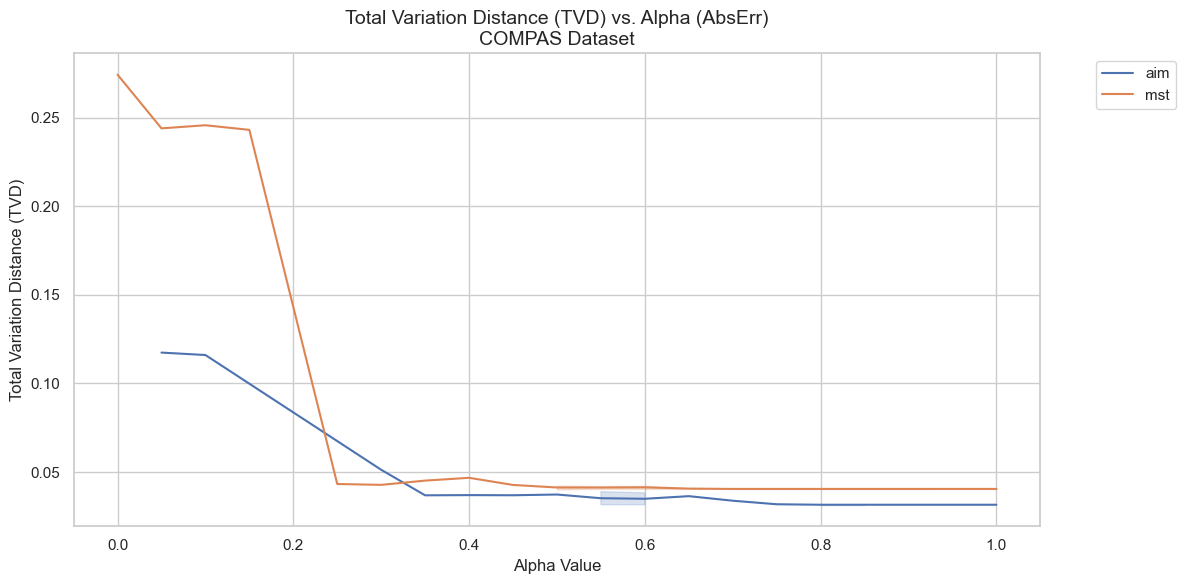

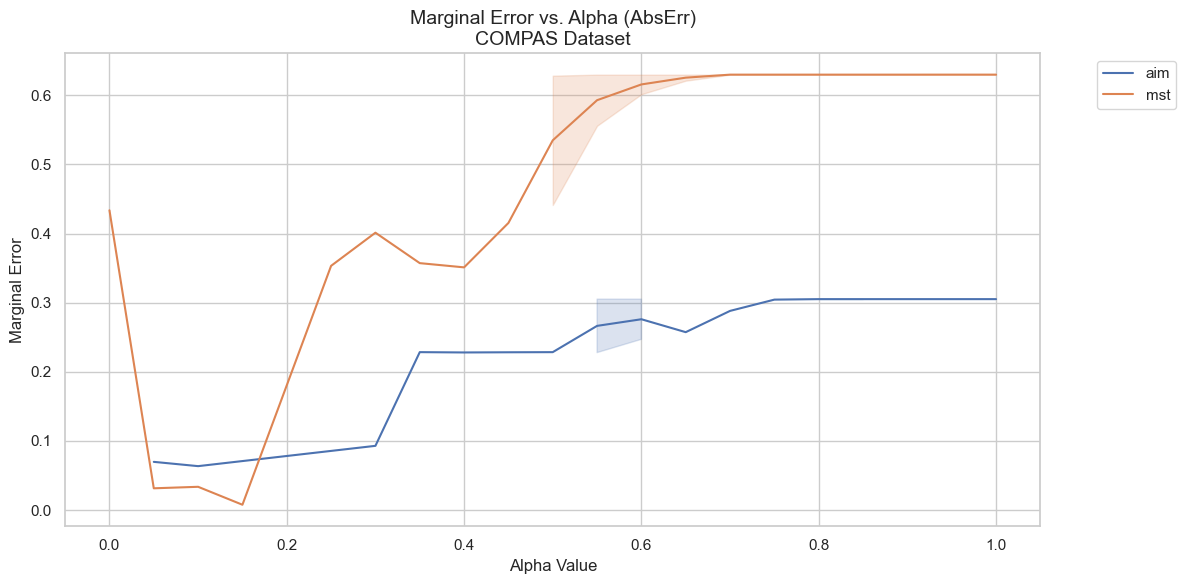

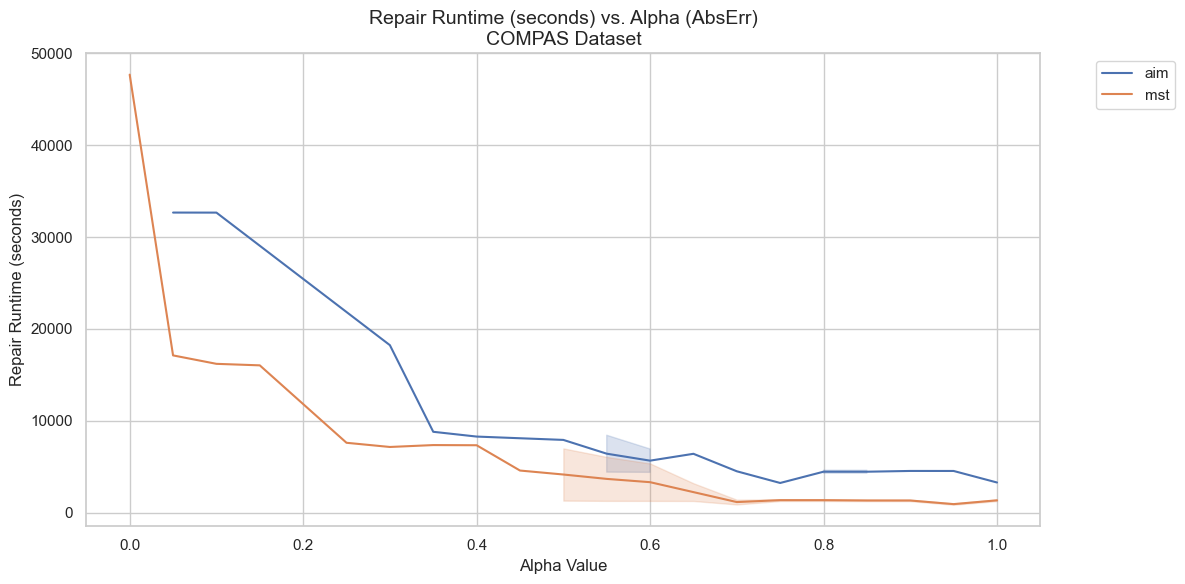

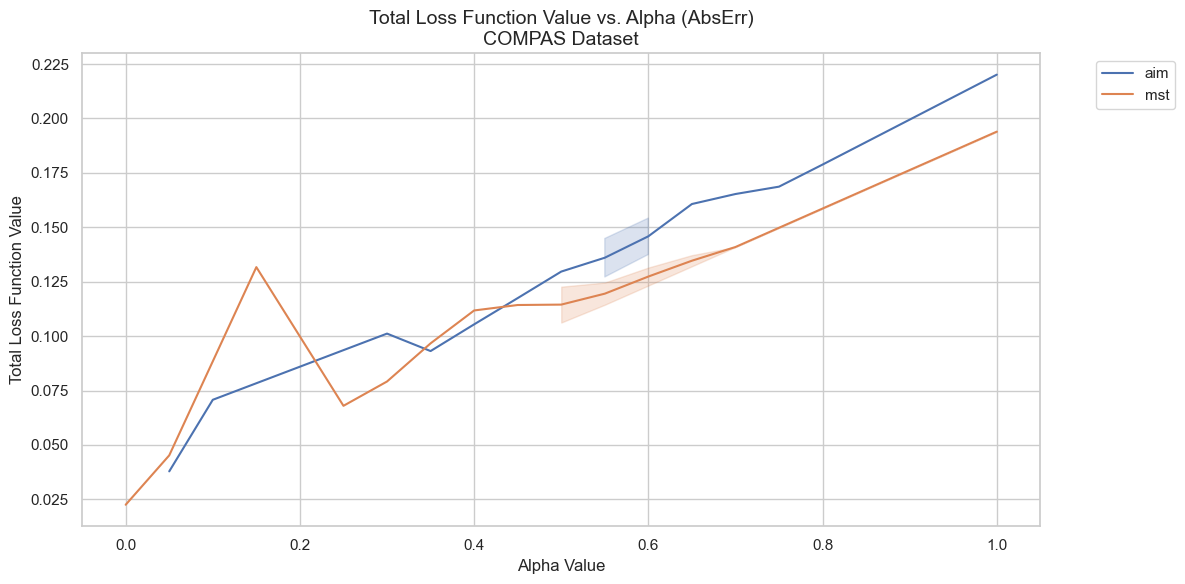

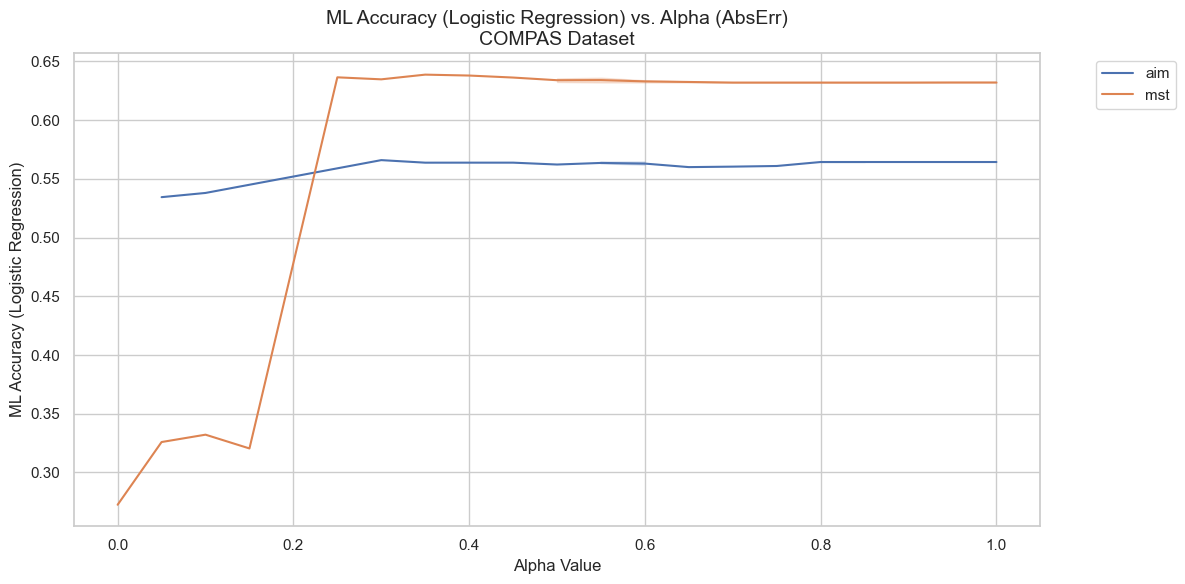


Dataset: TAX



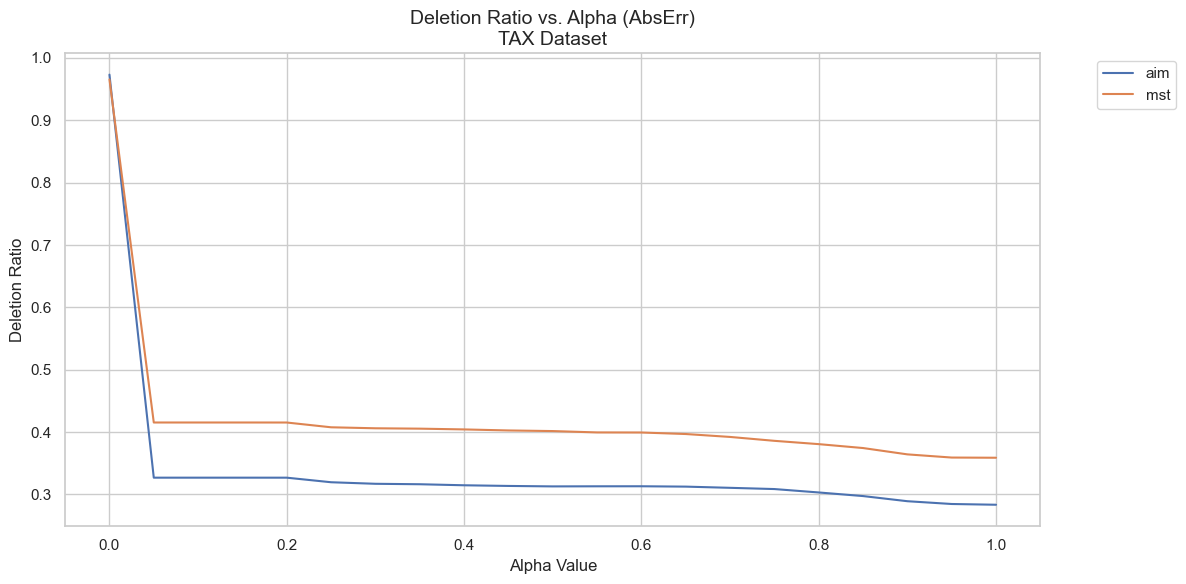

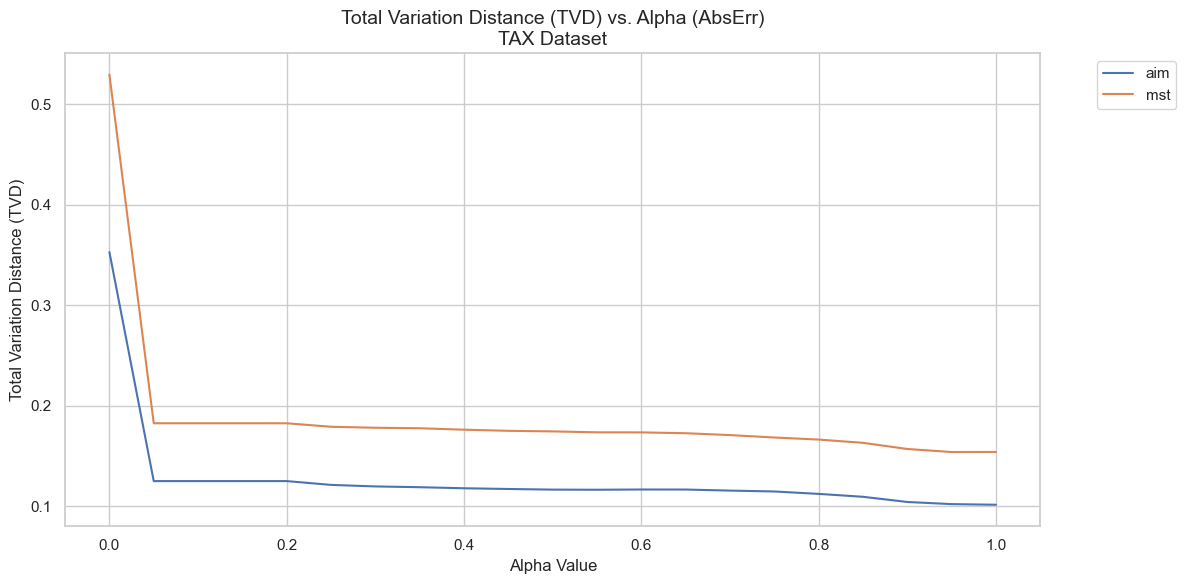

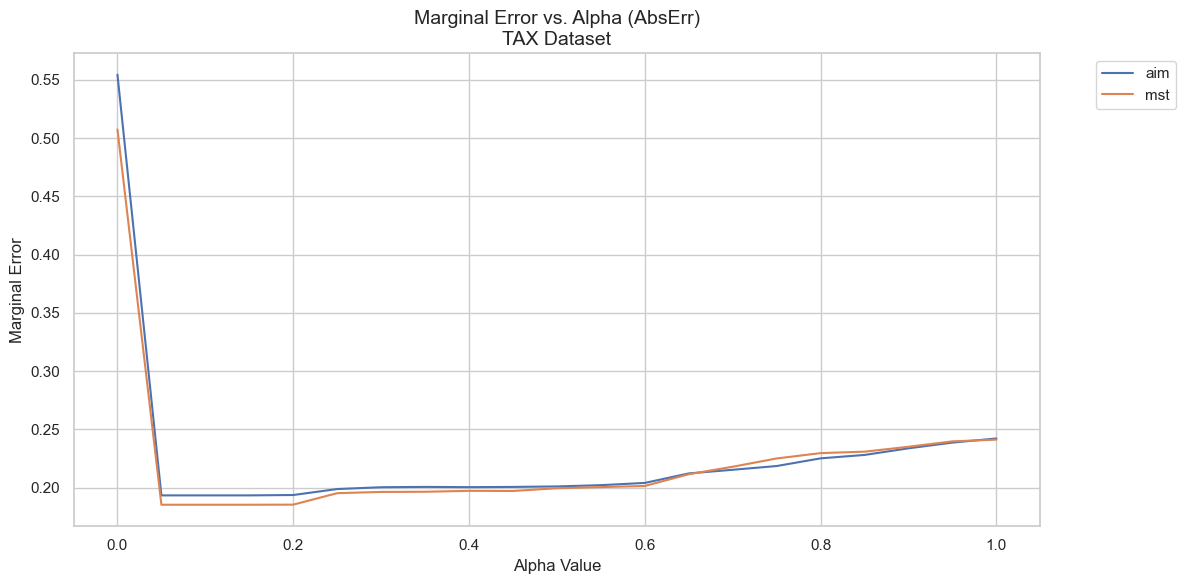

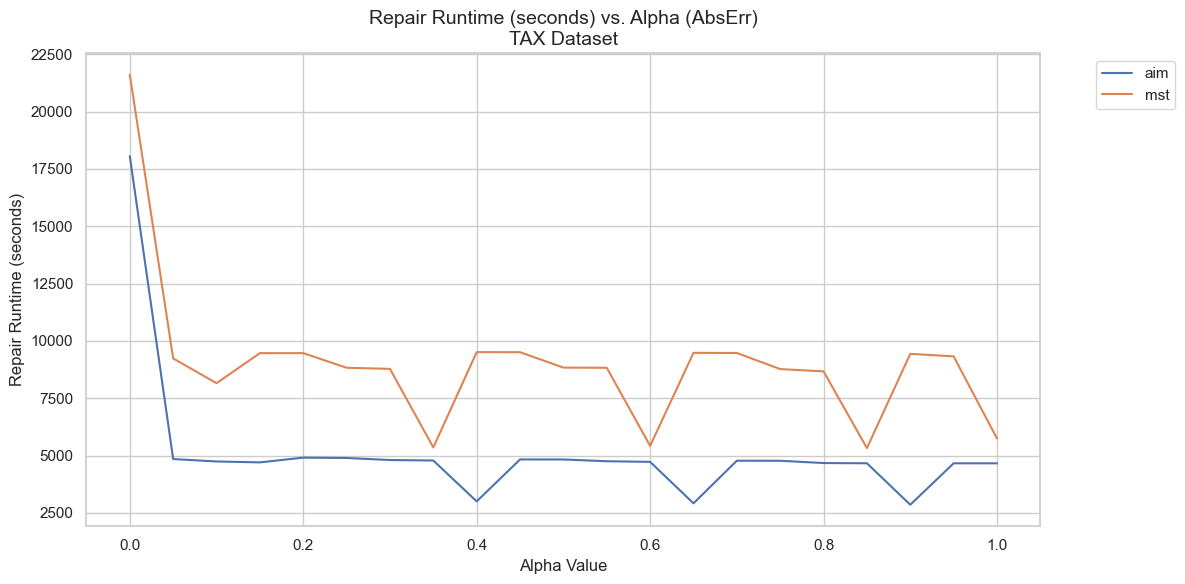

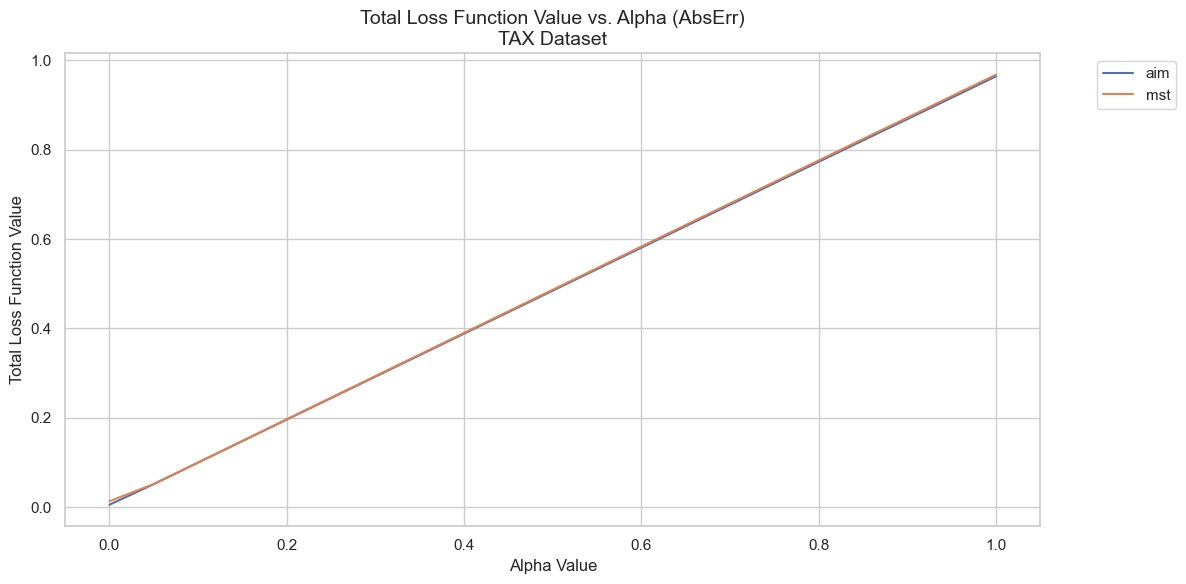

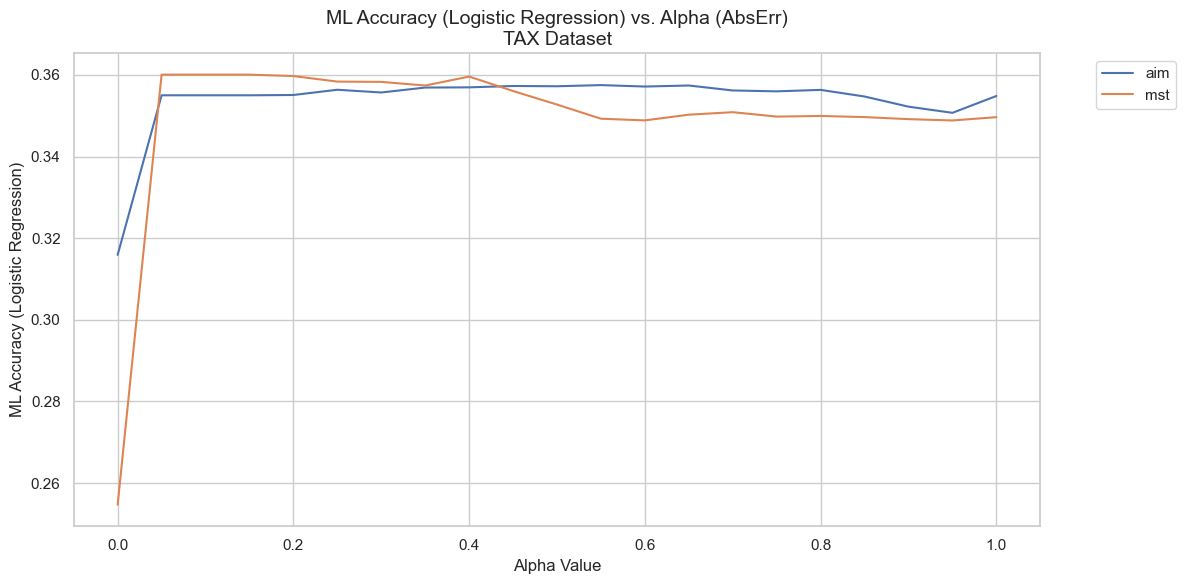

In [2]:
metrics = {
    'deletion_ratio_ratio': 'Deletion Ratio',
    'tvd_2way_repaired_avg': 'Total Variation Distance (TVD)',
    'marginals_error_repaired_avg': 'Marginal Error',
    'runtime_repairing': 'Repair Runtime (seconds)',
    'loss_function_repaired_total': 'Total Loss Function Value',
    'ml_accuracy_repaired_logistic_regression': 'ML Accuracy (Logistic Regression)'
}

def plot_metric_vs_alpha(dataset_name, metric_col, metric_title):
    ds_df = df[(df['dataset'] == dataset_name) & (df['alpha'].notna())].copy()
    if ds_df.empty:
        return
    
    plt.figure(figsize=(12, 6))
    # Note: Using engine as hue since we are mostly comparing AIM vs MST in this sweep
    sns.lineplot(data=ds_df, x='alpha', y=metric_col, hue='engine', markers=True, dashes=False)
    plt.title(f"{metric_title} vs. Alpha (AbsErr)\n{dataset_name.upper()} Dataset", fontsize=14)
    plt.xlabel("Alpha Value", fontsize=12)
    plt.ylabel(metric_title, fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

datasets = df['dataset'].dropna().unique()
for ds in datasets:
    print(f"\n{'='*50}")
    print(f"Dataset: {ds.upper()}")
    print(f"{'='*50}\n")
    for m_col, m_title in metrics.items():
        if m_col in df.columns:
            try:
                plot_metric_vs_alpha(ds, m_col, m_title)
            except Exception as e:
                print(f"Error plotting {m_title}: {e}")
